In [3]:
from sentence_transformers import SentenceTransformer

In [4]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

In [5]:
model = SentenceTransformer('clip-ViT-B-32')

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


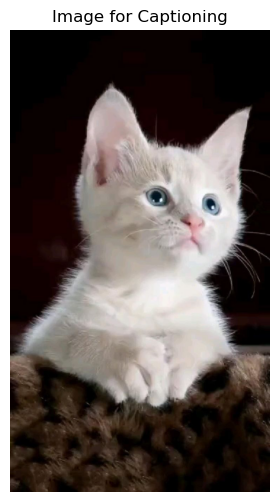

In [9]:
image = 'cat on table.png'
img1 = Image.open(image)
plt.figure(figsize=(6,6))

plt.imshow(img1)
plt.axis('off')
plt.title('Image for Captioning')
plt.show()

In [42]:
text_description=['Two dogs in the snow',
                 'A cat on a table',
                 'A happy dog playing ball',
                 'A dog sleeping on a counch',
                 'Two cats fighting in a garden',
                 ]

In [43]:
def display_img_to_compare(image,text_description):
    img1 = Image.open(image)

    
    text_emb = model.encode(text_description)
    img1_emb = model.encode(img1)

    similarty_score = np.dot(text_emb,img1_emb.T)

    best_match_index = np.argmax(similarty_score)
    best_match = text_description[best_match_index]

    print('Best match for the image is',best_match,similarty_score[best_match_index])
    plt.figure(figsize=(6,6))
    plt.imshow(img1)
    plt.axis('off')
    plt.title('Image for Captioning')
    plt.show()

    

Best match for the image is A cat on a table 26.902971


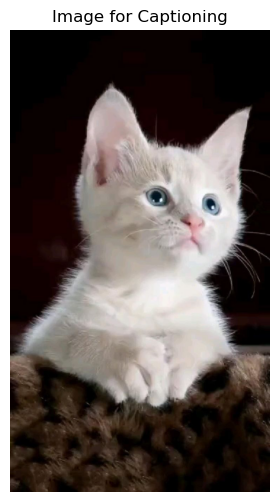

In [44]:
display_img_to_compare(image,text_description)

In [45]:
img2 ='man.jpg'

Best match for the image is A dog sleeping on a counch 18.312458


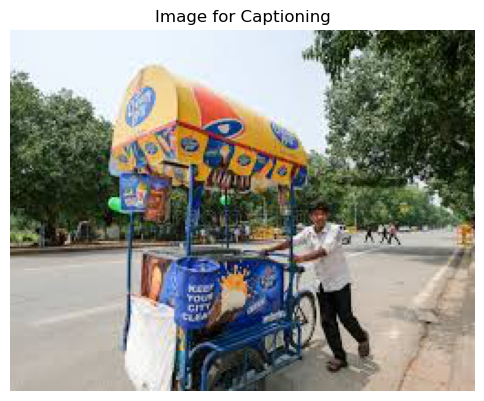

In [46]:
display_img_to_compare(img2,text_description)